# 03 — Dataset & DataLoader Construction (MOTOR decoding)

Builds causal, overlapping temporal windows over the processed MOTOR-task ROI
bundles from `02_data.ipynb`, assembles subject-level train/val/test splits,
and produces PyTorch `Dataset`/`DataLoader` objects for the four planned
decoding experiments.

Workflow (per project convention): prototype each step inline and verify it,
then consolidate the verified logic into `src/neurolens/data_setup.py`.

See [docs/project-handoff-summary.md §10-14](../docs/project-handoff-summary.md#10-meaning-of-the-saved-arrays)
and [docs/ml-design-report.md §2](../docs/ml-design-report.md#2-input--output-specification).


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "environment.yml").exists() or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate the NeuroLens repository root.")


PROJECT_ROOT = find_project_root()
PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed" / "hcp_ya_s1200" / "runs"
TASK = "MOTOR"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESSED_ROOT:", PROCESSED_ROOT)


PROJECT_ROOT: /Users/srinivasgovindasurampudi/Projects/neurolens-rag
PROCESSED_ROOT: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/runs


## 1. Inspect processed bundles

List every completed subject/run and its class distribution before building any windows.

In [2]:
subject_dirs = sorted(p for p in PROCESSED_ROOT.glob("sub-*") if p.is_dir())

rows = []
for subj_dir in subject_dirs:
    subject_id = subj_dir.name.replace("sub-", "")
    for run_dir in sorted(subj_dir.glob(f"tfMRI_{TASK}_*")):
        run = run_dir.name.split("_")[-1]
        meta = json.loads((run_dir / "metadata.json").read_text())
        y = np.load(run_dir / "y.npy")
        classes, counts = np.unique(y, return_counts=True)
        rows.append({
            "subject_id": subject_id,
            "run": run,
            "n_timepoints": meta["validation"]["n_timepoints"],
            "n_rois": meta["validation"]["n_rois"],
            "n_conditions": meta["validation"]["n_conditions"],
            "baseline_count": meta["validation"]["baseline_volume_count"],
            "task_volume_count": meta["validation"]["task_volume_count"],
            "classes_present": classes.tolist(),
        })

bundle_summary = pd.DataFrame(rows)
bundle_summary


,subject_id,run,n_timepoints,n_rois,n_conditions,baseline_count,task_volume_count,classes_present
0,100307,LR,284,300,5,68,216,"[0, 1, 2, 3, 4, 5]"
1,100307,RL,284,300,5,68,216,"[0, 1, 2, 3, 4, 5]"
2,100408,LR,284,300,5,68,216,"[0, 1, 2, 3, 4, 5]"
3,100408,RL,284,300,5,68,216,"[0, 1, 2, 3, 4, 5]"
4,101006,LR,284,300,5,68,216,"[0, 1, 2, 3, 4, 5]"
5,101006,RL,284,300,5,68,216,"[0, 1, 2, 3, 4, 5]"
6,101107,LR,284,300,5,68,216,"[0, 1, 2, 3, 4, 5]"
7,101107,RL,284,300,5,68,216,"[0, 1, 2, 3, 4, 5]"
8,101309,LR,284,300,5,68,216,"[0, 1, 2, 3, 4, 5]"
9,101309,RL,284,300,5,68,216,"[0, 1, 2, 3, 4, 5]"


## 2. Prototype: causal windows for a single run

Window length 32, stride 2, causal sequence-to-one: `X[start:end] -> y[end-1]`.

In [3]:
WINDOW_LENGTH = 32
STRIDE = 2

example_dir = PROCESSED_ROOT / "sub-100307" / "tfMRI_MOTOR_LR"
X_example = np.load(example_dir / "X.npy")
y_example = np.load(example_dir / "y.npy")
valid_mask_example = np.load(example_dir / "valid_mask.npy")

example_windows = []
for end in range(WINDOW_LENGTH, X_example.shape[0] + 1, STRIDE):
    start = end - WINDOW_LENGTH
    if not bool(valid_mask_example[start:end].all()):
        continue
    example_windows.append((start, end))

print(f"run length = {X_example.shape[0]} volumes -> {len(example_windows)} windows")
print("first window:", example_windows[0], "-> x shape", X_example[example_windows[0][0]:example_windows[0][1]].shape,
      "target y =", y_example[example_windows[0][1] - 1])
print("last window: ", example_windows[-1])


run length = 284 volumes -> 127 windows
first window: (0, 32) -> x shape (32, 300) target y = 2
last window:  (252, 284)


## 3. Subject-level split

All windows from a subject stay in the same split — never split at the window level (leakage risk from overlapping windows).

In [4]:
TRAIN_SUBJECTS = ["100307", "100408", "101006"]
VAL_SUBJECTS = ["101107"]
TEST_SUBJECTS = ["101309"]

assert set(TRAIN_SUBJECTS) & set(VAL_SUBJECTS) == set()
assert set(TRAIN_SUBJECTS) & set(TEST_SUBJECTS) == set()
assert set(VAL_SUBJECTS) & set(TEST_SUBJECTS) == set()
assert set(TRAIN_SUBJECTS + VAL_SUBJECTS + TEST_SUBJECTS) == set(bundle_summary["subject_id"])

print("train:", TRAIN_SUBJECTS)
print("val:  ", VAL_SUBJECTS)
print("test: ", TEST_SUBJECTS)


train: ['100307', '100408', '101006']
val:   ['101107']
test:  ['101309']


## 4. Prototype: full window index + Dataset/DataLoader across all subjects/runs

Preload every run's arrays once (the whole processed corpus is a few MB), build the global window index, then filter by split.

In [5]:
def load_run(subject_id: str, run: str) -> dict:
    run_dir = PROCESSED_ROOT / f"sub-{subject_id}" / f"tfMRI_{TASK}_{run}"
    return {
        "X": np.load(run_dir / "X.npy"),
        "y": np.load(run_dir / "y.npy"),
        "y_hrf": np.load(run_dir / "y_hrf.npy"),
        "valid_mask": np.load(run_dir / "valid_mask.npy"),
        "metadata": json.loads((run_dir / "metadata.json").read_text()),
    }


ALL_SUBJECTS = TRAIN_SUBJECTS + VAL_SUBJECTS + TEST_SUBJECTS
RUNS = ["LR", "RL"]

run_arrays = {
    (sid, run): load_run(sid, run)
    for sid in ALL_SUBJECTS
    for run in RUNS
    if (PROCESSED_ROOT / f"sub-{sid}" / f"tfMRI_{TASK}_{run}").exists()
}

all_windows = []
for (sid, run), arr in run_arrays.items():
    n_t = arr["X"].shape[0]
    for end in range(WINDOW_LENGTH, n_t + 1, STRIDE):
        start = end - WINDOW_LENGTH
        if not bool(arr["valid_mask"][start:end].all()):
            continue
        all_windows.append((sid, run, start, end))

print("total windows across all subjects/runs:", len(all_windows))


class PrototypeWindowDataset(Dataset):
    def __init__(self, windows, subjects):
        subj_set = set(subjects)
        self.windows = [w for w in windows if w[0] in subj_set]

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        sid, run, start, end = self.windows[idx]
        arr = run_arrays[(sid, run)]
        target = end - 1
        return {
            "x": torch.from_numpy(arr["X"][start:end].astype(np.float32)),
            "y": torch.tensor(int(arr["y"][target]), dtype=torch.long),
            "y_hrf": torch.from_numpy(arr["y_hrf"][target].astype(np.float32)),
            "subject_id": sid,
            "task": TASK,
            "run": run,
            "target_volume": target,
        }


proto_train_ds = PrototypeWindowDataset(all_windows, TRAIN_SUBJECTS)
proto_val_ds = PrototypeWindowDataset(all_windows, VAL_SUBJECTS)
proto_test_ds = PrototypeWindowDataset(all_windows, TEST_SUBJECTS)

print(f"train={len(proto_train_ds)} val={len(proto_val_ds)} test={len(proto_test_ds)} windows")

proto_train_loader = DataLoader(proto_train_ds, batch_size=64, shuffle=True)
batch = next(iter(proto_train_loader))
print({k: (v.shape if torch.is_tensor(v) else type(v)) for k, v in batch.items()})
assert batch["x"].shape[1:] == (WINDOW_LENGTH, 300)


total windows across all subjects/runs: 1270
train=762 val=254 test=254 windows
{'x': torch.Size([64, 32, 300]), 'y': torch.Size([64]), 'y_hrf': torch.Size([64, 5]), 'subject_id': <class 'list'>, 'task': <class 'list'>, 'run': <class 'list'>, 'target_volume': torch.Size([64])}


## 5. Class weights from training data only

`weight[c] = n_train_samples / (num_classes * samples_in_class_c)`.

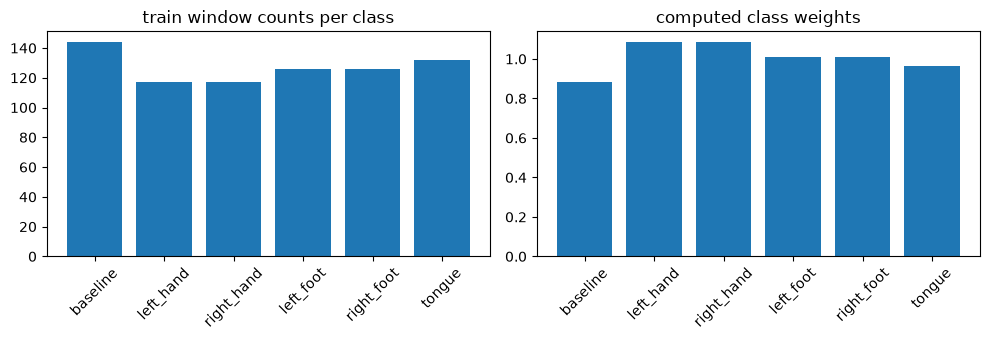

{'baseline': np.float64(0.882), 'left_hand': np.float64(1.085), 'right_hand': np.float64(1.085), 'left_foot': np.float64(1.008), 'right_foot': np.float64(1.008), 'tongue': np.float64(0.962)}


In [6]:
CLASS_TO_CONDITION = {int(k): v for k, v in run_arrays[(TRAIN_SUBJECTS[0], "LR")]["metadata"]["target_construction"]["class_to_condition"].items()}
NUM_CLASSES = len(CLASS_TO_CONDITION)
NUM_CONDITIONS = len(run_arrays[(TRAIN_SUBJECTS[0], "LR")]["metadata"]["target_construction"]["condition_names"])

train_labels = np.array([
    run_arrays[(sid, run)]["y"][end - 1]
    for sid, run, start, end in all_windows
    if sid in set(TRAIN_SUBJECTS)
])
counts = np.bincount(train_labels, minlength=NUM_CLASSES).astype(np.float64)
class_weights = len(train_labels) / (NUM_CLASSES * counts)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar([CLASS_TO_CONDITION[c] for c in range(NUM_CLASSES)], counts)
axes[0].set_title("train window counts per class")
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar([CLASS_TO_CONDITION[c] for c in range(NUM_CLASSES)], class_weights)
axes[1].set_title("computed class weights")
axes[1].tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

print(dict(zip(CLASS_TO_CONDITION.values(), class_weights.round(3))))


## 6. Refactor into `src/neurolens/data_setup.py`

The prototyped logic above (run loading, window indexing, subject-level
filtering, class weights, `Dataset`/`DataLoader` construction) has been
consolidated into `src/neurolens/data_setup.py::make_dataloaders`. Re-running
through the module should reproduce the same window counts as the prototype
above.

In [7]:
import sys

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from neurolens.data_setup import (
    MOTOR_TEST_SUBJECTS,
    MOTOR_TRAIN_SUBJECTS,
    MOTOR_VAL_SUBJECTS,
    make_dataloaders,
)

assert MOTOR_TRAIN_SUBJECTS == TRAIN_SUBJECTS
assert MOTOR_VAL_SUBJECTS == VAL_SUBJECTS
assert MOTOR_TEST_SUBJECTS == TEST_SUBJECTS

train_loader, val_loader, test_loader, info = make_dataloaders(
    PROCESSED_ROOT, task=TASK, window_length=WINDOW_LENGTH, stride=STRIDE, batch_size=64
)

assert info["n_train_windows"] == len(proto_train_ds)
assert info["n_val_windows"] == len(proto_val_ds)
assert info["n_test_windows"] == len(proto_test_ds)
assert torch.allclose(info["class_weights"], torch.tensor(class_weights, dtype=torch.float32), atol=1e-5)

print("data_setup.make_dataloaders reproduces the prototyped windows/splits/class-weights exactly.")
print({k: v for k, v in info.items() if k != "class_weights"})


data_setup.make_dataloaders reproduces the prototyped windows/splits/class-weights exactly.
{'num_classes': 6, 'num_conditions': 5, 'n_train_windows': 762, 'n_val_windows': 254, 'n_test_windows': 254, 'class_to_condition': {'0': 'baseline', '1': 'left_hand', '2': 'right_hand', '3': 'left_foot', '4': 'right_foot', '5': 'tongue'}, 'condition_names': ['left_hand', 'right_hand', 'left_foot', 'right_foot', 'tongue']}


## Summary

- 5 subjects × 2 runs (LR/RL) × 284 volumes, window length 32, stride 2, causal sequence-to-one.
- Subject-level split: train = `100307, 100408, 101006`, val = `101107`, test = `101309`.
- 6 classes (baseline + 5 MOTOR conditions), 5 HRF regression channels.
- Verified logic now lives in `src/neurolens/data_setup.py` and is reused by `04_models.ipynb` and `05_train_eval_compare.ipynb`.
